In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("./cor_da_justica.csv")
df = df.drop(columns="Unnamed: 0", axis=1)

In [18]:
df = df.rename(columns={"ementa.1": "ementa_principal", "keywords.1": "keywords_principal"})

In [19]:
df.head(12)

,ementa,ementaDetalhada,keywords,uris.uriAutores,uris.uriPropPrincipal,uris.uriUltimoRelator,nome,cpf,foto,sexo,nascimento,local_nascimento,escolaridade,orgão,ementa_principal,situacao,tipo,keywords_principal,cor
0,Dispõe sobre a obrigatoriedade de fotografia n...,Altera a Lei nº 7.444 de 20 de dezembro de 1985.,"Alteração, Lei do Processamento Eletrônico do ...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,CARLOS FREDERICO THEODORO NADER,85176427753,https://www.camara.leg.br/internet/deputado/ba...,M,1965-09-21,Barra Mansa - RJ,Superior,NaN,vazio,NaN,NaN,NaN,#NE
1,Garante ao acertador de qualquer tipo de jogo ...,NaN,"Garantia, omissão, identificação, ganhador, lo...",https://dadosabertos.camara.leg.br/api/v2/prop...,https://dadosabertos.camara.leg.br/api/v2/prop...,https://dadosabertos.camara.leg.br/api/v2/depu...,ANDRES NAVARRO SANCHEZ,7078570820,https://www.camara.leg.br/internet/deputado/ba...,M,1963-12-24,Limeira - SP,Ensino Fundamental,NaN,"Acrescenta art. 10-B à Lei n° 9.613, de 3 de m...",Aguardando Parecer,Projeto de Lei,"Alteração, Lei de Lavagem de Dinheiro, obrigat...",BRANCA
2,Dispõe sobre a obrigatoriedade das prestadoras...,NaN,"Obrigatoriedade, concessionária, telefone celu...",https://dadosabertos.camara.leg.br/api/v2/prop...,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,FRANCISCO RODRIGUES DE ALENCAR FILHO,26451379700,https://www.camara.leg.br/internet/deputado/ba...,M,1949-10-19,Rio de Janeiro - RJ,Mestrado,NaN,"Altera o inciso IV do art. 3º da Lei nº 9.472,...",Aguardando Parecer,Projeto de Lei,"Alteração, Lei Geral das Telecomunicações, dis...",#NE
3,Institui o dia 02 de julho como data histórica...,NaN,"Criação, Dia Nacional da Independência do Bras...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,DOUGLAS DE PAULO VIEGAS,25519061807,https://www.camara.leg.br/internet/deputado/ba...,M,1979-06-19,São Paulo - SP,NaN,NaN,vazio,NaN,NaN,NaN,PARDA
4,Altera o inciso I do § 1º do art. 68 da Lei nº...,NaN,"Alteração, Nova Lei de Patentes, licenciament...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,CÁSSIO MURILO GALDINO DE ARAÚJO,3182571494,https://www.camara.leg.br/internet/deputado/ba...,M,1980-07-02,Pocinhos - PB,Superior,NaN,vazio,NaN,NaN,NaN,BRANCA
5,Regulamenta o § 7º do art. 37 da Constituição ...,Fixa um período de impedimento ou quarentena d...,"Regulamentação, Constituição Federal, requisit...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,GILSON MARQUES VIEIRA,824207939,https://www.camara.leg.br/internet/deputado/ba...,M,1981-04-12,Rio do Sul - SC,Pós-Graduação,NaN,vazio,NaN,NaN,NaN,BRANCA
6,Estabelece prazo de impedimento para o ex-pres...,"Fixa o prazo de ""quarentena"" de um ano, a part...","Regulamentação, Constituição Federal, fixação,...",https://dadosabertos.camara.leg.br/api/v2/prop...,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,MÁRIO ASSAD JÚNIOR,53724941668,https://www.camara.leg.br/internet/deputado/ba...,M,1965-08-11,Manhuaçu - MG,Superior,NaN,Regulamenta o § 7º do art. 37 da Constituição ...,Aguardando Parecer,Projeto de Lei,"Regulamentação, Constituição Federal, requisit...",#NE
7,"Altera dispositivos da Lei nº 9.648, de 27 de ...",NaN,"Alteração, lei federal, aumento, percentual, c...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,JOSÉ MOHAMED JANENE,14430517991,https://www.camara.leg.br/internet/deputado/ba...,M,1955-09-12,Santo Inácio - PR,Secundário,NaN,vazio,NaN,NaN,NaN,#NE
8,"Revigora a Lei nº 2.689, de 20 de Dezembro de ...","Restabelece a lei que denomina ""Dois de Julho""...","Restabelecimento, lei federal, denominação, Ae...",https://dadosabertos.camara.leg.br/api/v2/prop...,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,COLBERT MARTINS DA SILVA FILHO,13236164549,https://www.camara.leg.br/internet/deputado/ba...

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7406 entries, 0 to 7405
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ementa                 7107 non-null   object 
 1   ementaDetalhada        444 non-null    object 
 2   keywords               3877 non-null   object 
 3   uris.uriAutores        7406 non-null   object 
 4   uris.uriPropPrincipal  1679 non-null   object 
 5   uris.uriUltimoRelator  2574 non-null   object 
 6   nome                   7406 non-null   object 
 7   cpf                    7406 non-null   int64  
 8   foto                   7406 non-null   object 
 9   sexo                   7406 non-null   object 
 10  nascimento             7406 non-null   object 
 11  local_nascimento       7406 non-null   object 
 12  escolaridade           7234 non-null   object 
 13  orgão                  0 non-null      float64
 14  ementa_principal       7406 non-null   object 
 15  situ

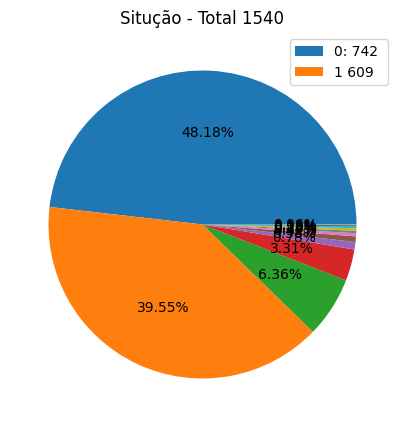

In [21]:
situacao = df["situacao"].value_counts().reset_index()


fig, ax = plt.subplots(1,1,figsize=(12,5))
ax.pie(situacao["count"], autopct="%.2f%%")
ax.set_title(f"Situção - Total {df['situacao'].count()}")
ax.legend([f"0: {situacao['count'][0]} ", f"1 {situacao['count'][1]}"])
plt.show()

In [22]:
palavra_chave = df["keywords"].value_counts().reset_index()
teste = palavra_chave["keywords"].apply(lambda x: x.split(', '))
key_word = []
for key in teste:
    for word in key:
        key_word.append(word)

keyword = pd.DataFrame(key_word)

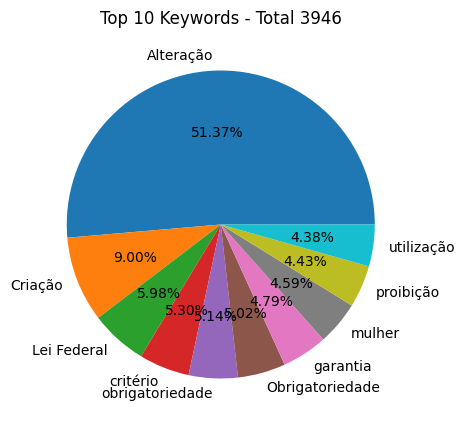

In [23]:
top10_keywords = keyword[0].value_counts().reset_index()
top10_keywords = top10_keywords.nlargest(10, "count")
fig, ax = plt.subplots(1,1,figsize=(12,5))
ax.pie(top10_keywords["count"], labels=top10_keywords[0],autopct="%.2f%%")
ax.set_title(f"Top 10 Keywords - Total {top10_keywords['count'].sum()}")
plt.show()


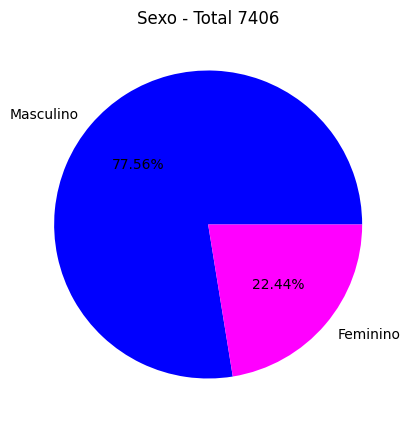

In [24]:
sexo = df["sexo"].value_counts().reset_index()
sexo["sexo"] = sexo["sexo"].map({"M": "Masculino", "F": "Feminino"})
fig, ax = plt.subplots(1,1,figsize=(12,5))
ax.pie(sexo["count"], labels=sexo["sexo"],autopct="%.2f%%", colors=["blue", "magenta",])
ax.set_title(f"Sexo - Total {sexo['count'].sum()}")
plt.show()